# Scratch baselines with SAM — CustomCNN, ResNet18, ViT (3‑channel)
- Chest X-ray Pneumonia vs Normal (Kaggle) — **3-channel (RGB)** scratch baselines.
- We convert grayscale to RGB with `T.Grayscale(3)` so all models receive 3 channels.
- Same preprocessing across models; cosine LR with warmup; early stopping on AUROC.
- Final metrics reported at **0.5** and at a **recall‑first** operating point (target recall = 0.95).


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
ZIP_PATH = "/content/drive/MyDrive/Data/chest-xray-pneumonia.zip"
DEST     = "/content/data"          # local fast disk
!mkdir -p "$DEST"

# sanity check
!ls -lh "$ZIP_PATH"


-rw------- 1 root root 2.3G Sep 28  2019 /content/drive/MyDrive/Data/chest-xray-pneumonia.zip


In [ ]:
# -q: quiet, -o: overwrite if re-running
!unzip -q -o "$ZIP_PATH" -d "$DEST"

# show what got extracted
!find "$DEST" -maxdepth 2 -type d -print


/content/data
/content/data/chest_xray
/content/data/chest_xray/train
/content/data/chest_xray/val
/content/data/chest_xray/chest_xray
/content/data/chest_xray/__MACOSX
/content/data/chest_xray/test


In [ ]:
# Clean imports + path setup
import sys, time, warnings
from pathlib import Path
try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Resolve project root (directory containing `src/`)
proj_root = Path.cwd()
for _ in range(5):
    if (proj_root / "src").exists():
        break
    proj_root = proj_root.parent
sys.path.append(str(proj_root))

# Import project API
from src import (
    DataCfg, TrainCfg, set_seed, get_device, build_dataloaders,
    build_custom_cnn, build_resnet18, build_vit_scratch,
    train_model, evaluate, choose_threshold_by_min_recall, summarize_at_threshold,
    plot_curve, plot_two_series, diag_plots, add_result, result_registry
)
import numpy as np, pandas as pd, torch

set_seed(42)
DEVICE = get_device()
DEVICE


device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# === Paths/config ===
DATASET_DIR = Path("/content/data/chest_xray")  # <--- EDIT THIS IF NEEDED

# Keep split identical across notebooks for fair comparison
data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,
    batch_size=32,
    num_workers=4,          # 0 on macOS avoids "MallocStackLogging" noise
    pin_memory=True,
    use_stratified_val=True,
    val_ratio=0.20,         # use the same val split you used elsewhere
    gray_to_rgb=True,       # 3-CHANNEL: expand grayscale -> RGB
    compute_norm_stats=True,# compute mean/std from train set (3ch replicated)
    balance_sampler=True
)

train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, device=DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
print("Train counts:", info["train_counts"])

# Class weights: when balance_sampler=True, set None to avoid double-correction
class_weights = None

# Sanity check: confirm 3-channel
xb, yb = next(iter(train_loader))
print("Batch shape:", tuple(xb.shape))  # expect (B, 3, 224, 224)
del xb, yb


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079, 3106]
Batch shape: (32, 3, 224, 224)


In [ ]:
# Shared training cfg for scratch runs **with SAM**
scratch_sam = TrainCfg(
    epochs=100, patience=15, monitor="va_auroc",
    base_lr=3e-4, weight_decay=0.2,     # ViT defaults; CNN/ResNet override below
    clip_grad_norm=1.0, use_amp=False,
    use_sam=True, sam_rho=0.1,          # default; per-model overrides below
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    target_recall=0.95,
    llrd=False, head_lr_mult=1.0
)


[CustomCNN-scratch-3ch+SAM] epoch 01/100  tr_loss=0.4295  val_loss=0.4496  val_acc=0.8166  val_f1=0.8621  val_auroc=0.9438  (no_improve=0)
[CustomCNN-scratch-3ch+SAM] epoch 02/100  tr_loss=0.4480  val_loss=0.8613  val_acc=0.6256  val_f1=0.6644  val_auroc=0.9402  (no_improve=1)
[CustomCNN-scratch-3ch+SAM] epoch 03/100  tr_loss=0.4010  val_loss=0.3259  val_acc=0.8739  val_f1=0.9118  val_auroc=0.9363  (no_improve=2)
[CustomCNN-scratch-3ch+SAM] epoch 04/100  tr_loss=0.3775  val_loss=0.3069  val_acc=0.8797  val_f1=0.9137  val_auroc=0.9465  (no_improve=0)
[CustomCNN-scratch-3ch+SAM] epoch 05/100  tr_loss=0.3946  val_loss=0.2856  val_acc=0.8835  val_f1=0.9176  val_auroc=0.9469  (no_improve=0)
[CustomCNN-scratch-3ch+SAM] epoch 06/100  tr_loss=0.3810  val_loss=0.2935  val_acc=0.8749  val_f1=0.9103  val_auroc=0.9552  (no_improve=0)
[CustomCNN-scratch-3ch+SAM] epoch 07/100  tr_loss=0.3815  val_loss=0.2869  val_acc=0.8701  val_f1=0.9110  val_auroc=0.9325  (no_improve=1)
[CustomCNN-scratch-3ch+SAM]

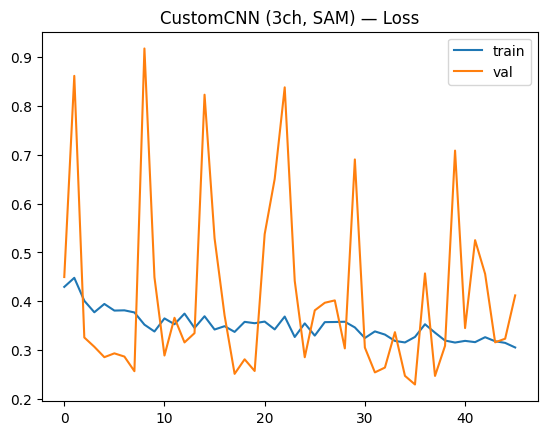

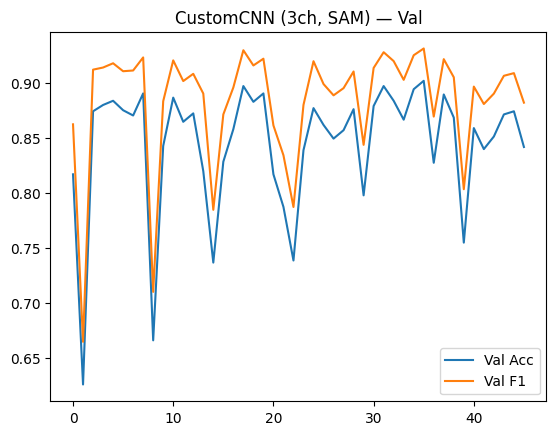

[CustomCNN-3ch+SAM @0.5] {'acc': 0.8301, 'precision': 0.8156, 'recall': 0.941, 'f1': 0.8738, 'auroc': np.float64(0.92), 'thr': 0.5}
[CustomCNN-3ch+SAM @Rec] {'acc': 0.7804, 'precision': 0.7485, 'recall': 0.9769, 'f1': 0.8476, 'auroc': np.float64(0.92), 'thr': 0.3415}


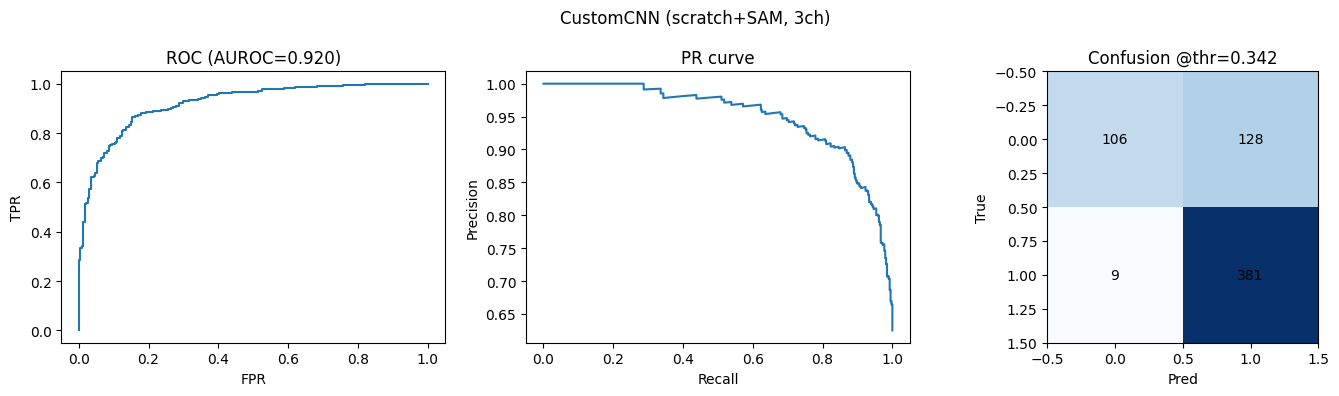

{'summary@0.5': {'acc': 0.8301282051282052,
  'precision': 0.8155555555555556,
  'recall': 0.941025641025641,
  'f1': 0.8738095238095238,
  'auroc': np.float64(0.9200306815691431),
  'thr': 0.5},
 'summary@recall': {'acc': 0.780448717948718,
  'precision': 0.7485265225933202,
  'recall': 0.9769230769230769,
  'f1': 0.8476084538375973,
  'auroc': np.float64(0.9200306815691431),
  'thr': 0.3415},
 'threshold': 0.3415,
 'time_sec': 1867.9259197711945,
 'params': 481698}

In [19]:
cfg = scratch_sam

cnn = build_custom_cnn(in_chans=3, num_classes=2, width=32, dropout=0.0)
t0 = time.time()
cnn_tr, cnn_hist, cnn_time = train_model(
    cnn, train_loader, val_loader, DEVICE, arch="custom_cnn",
    epochs=100, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=True, sam_rho=0.02,   # smaller rho works well for small CNNs
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    monitor="va_auroc", patience=10, clip_grad_norm=1.0,
    class_weights=class_weights, llrd=False, head_lr_mult=1.0, use_amp=False,
    tag="CustomCNN-scratch-3ch+SAM"
)
plot_curve(cnn_hist['tr_loss'], cnn_hist['va_loss'], "CustomCNN (3ch, SAM) — Loss")
plot_two_series(cnn_hist['va_acc'], "Val Acc", cnn_hist['va_f1'], "Val F1", "CustomCNN (3ch, SAM) — Val")
va = evaluate(cnn_tr, val_loader, DEVICE)
thr, *_ = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(cnn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[CustomCNN-3ch+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[CustomCNN-3ch+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("CustomCNN (scratch+SAM, 3ch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("CustomCNN (scratch+SAM, 3ch)", cnn_tr, sum_05, sum_reca, threshold=thr, time_sec=cnn_time)


[ResNet18-scratch-3ch+SAM] epoch 01/90  tr_loss=0.5788  val_loss=0.3267  val_acc=0.8625  val_f1=0.9012  val_auroc=0.9515  (no_improve=0)
[ResNet18-scratch-3ch+SAM] epoch 02/90  tr_loss=0.5936  val_loss=0.2859  val_acc=0.8749  val_f1=0.9113  val_auroc=0.9571  (no_improve=0)
[ResNet18-scratch-3ch+SAM] epoch 03/90  tr_loss=0.5477  val_loss=0.4009  val_acc=0.8472  val_f1=0.8886  val_auroc=0.9350  (no_improve=1)
[ResNet18-scratch-3ch+SAM] epoch 04/90  tr_loss=0.4318  val_loss=0.2552  val_acc=0.8863  val_f1=0.9208  val_auroc=0.9527  (no_improve=2)
[ResNet18-scratch-3ch+SAM] epoch 05/90  tr_loss=0.3711  val_loss=0.4437  val_acc=0.7966  val_f1=0.8437  val_auroc=0.9424  (no_improve=3)
[ResNet18-scratch-3ch+SAM] epoch 06/90  tr_loss=0.3397  val_loss=0.4056  val_acc=0.8434  val_f1=0.8832  val_auroc=0.9771  (no_improve=0)
[ResNet18-scratch-3ch+SAM] epoch 07/90  tr_loss=0.3487  val_loss=0.8878  val_acc=0.7087  val_f1=0.7574  val_auroc=0.9393  (no_improve=1)
[ResNet18-scratch-3ch+SAM] epoch 08/90  t

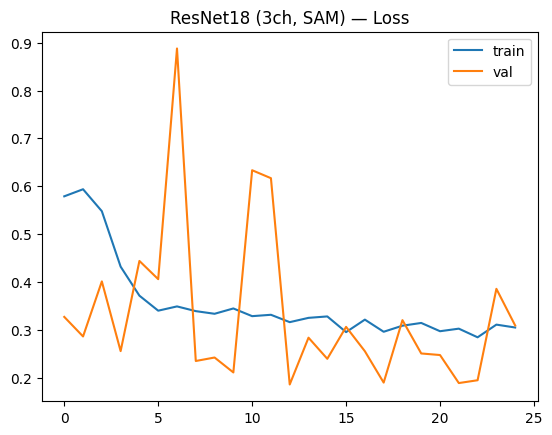

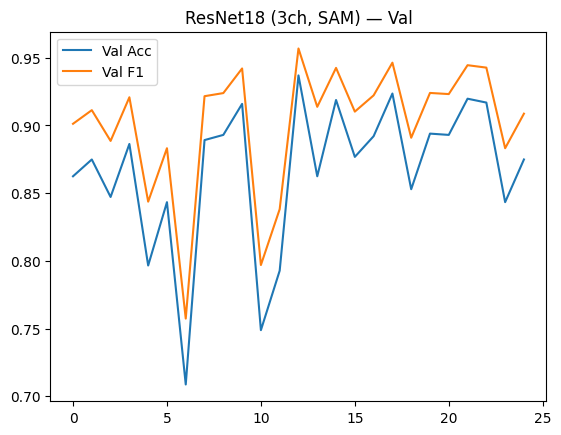

[ResNet18-3ch+SAM @0.5] {'acc': 0.8798, 'precision': 0.8637, 'recall': 0.959, 'f1': 0.9089, 'auroc': np.float64(0.9312), 'thr': 0.5}
[ResNet18-3ch+SAM @Rec] {'acc': 0.8429, 'precision': 0.8067, 'recall': 0.9846, 'f1': 0.8868, 'auroc': np.float64(0.9312), 'thr': 0.351}


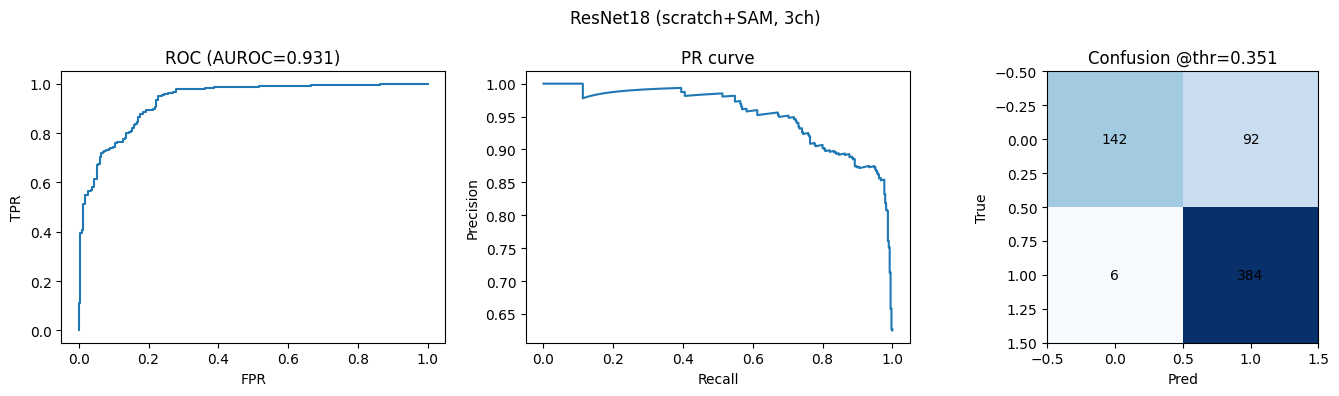

{'summary@0.5': {'acc': 0.8798076923076923,
  'precision': 0.8637413394919169,
  'recall': 0.958974358974359,
  'f1': 0.9088699878493317,
  'auroc': np.float64(0.9311856234933158),
  'thr': 0.5},
 'summary@recall': {'acc': 0.842948717948718,
  'precision': 0.8067226890756303,
  'recall': 0.9846153846153847,
  'f1': 0.8868360277136259,
  'auroc': np.float64(0.9311856234933158),
  'thr': 0.35100000000000003},
 'threshold': 0.35100000000000003,
 'time_sec': 395.09565472602844,
 'params': 11177538}

In [20]:
rn = build_resnet18(in_chans=3, num_classes=2, pretrained=False, conv_stem=False)
t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=90, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=True, sam_rho=0.05,  # robust rho for ResNet-18 with SAM
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    monitor="va_auroc", patience=10, clip_grad_norm=1.0,
    class_weights=class_weights, llrd=False, head_lr_mult=1.0, use_amp=False,
    tag="ResNet18-scratch-3ch+SAM"
)
plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 (3ch, SAM) — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 (3ch, SAM) — Val")
va = evaluate(rn_tr, val_loader, DEVICE)
thr, *_ = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-3ch+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-3ch+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (scratch+SAM, 3ch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (scratch+SAM, 3ch)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-scratch-3ch+SAM] epoch 01/120  tr_loss=0.6714  val_loss=0.5207  val_acc=0.7373  val_f1=0.7918  val_auroc=0.9016  (no_improve=0)
[ViT-scratch-3ch+SAM] epoch 02/120  tr_loss=0.5898  val_loss=0.4904  val_acc=0.7841  val_f1=0.8348  val_auroc=0.9224  (no_improve=0)
[ViT-scratch-3ch+SAM] epoch 03/120  tr_loss=0.5685  val_loss=0.4738  val_acc=0.7736  val_f1=0.8261  val_auroc=0.9251  (no_improve=0)
[ViT-scratch-3ch+SAM] epoch 04/120  tr_loss=0.5615  val_loss=0.5150  val_acc=0.7689  val_f1=0.8210  val_auroc=0.9303  (no_improve=0)
[ViT-scratch-3ch+SAM] epoch 05/120  tr_loss=0.5242  val_loss=0.5137  val_acc=0.7708  val_f1=0.8217  val_auroc=0.9312  (no_improve=0)
[ViT-scratch-3ch+SAM] epoch 06/120  tr_loss=0.5358  val_loss=0.5252  val_acc=0.7364  val_f1=0.7874  val_auroc=0.9417  (no_improve=0)
[ViT-scratch-3ch+SAM] epoch 07/120  tr_loss=0.4997  val_loss=0.4945  val_acc=0.7689  val_f1=0.8228  val_auroc=0.9072  (no_improve=1)
[ViT-scratch-3ch+SAM] epoch 08/120  tr_loss=0.5053  val_loss=0.3912  

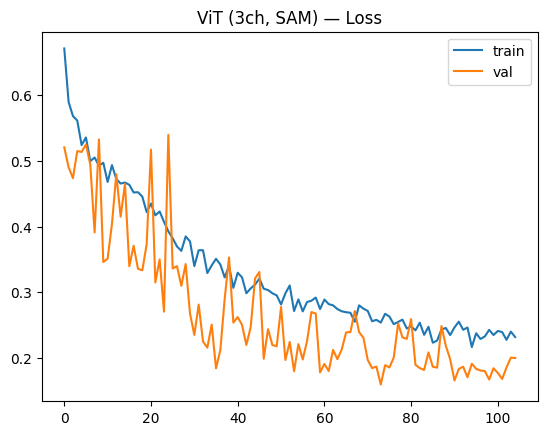

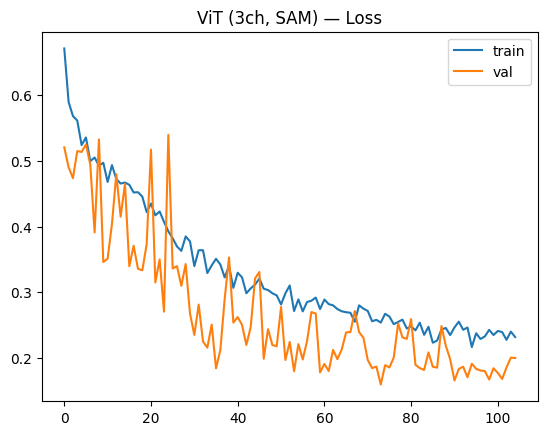

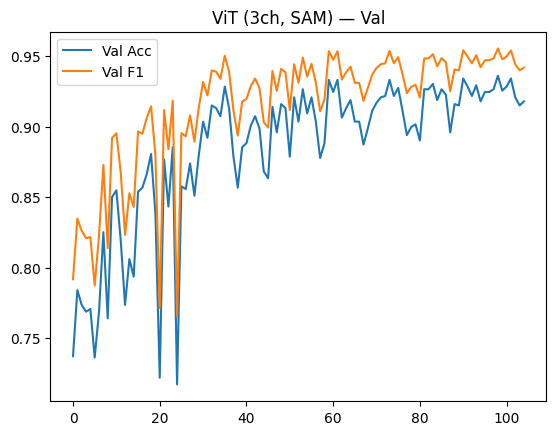

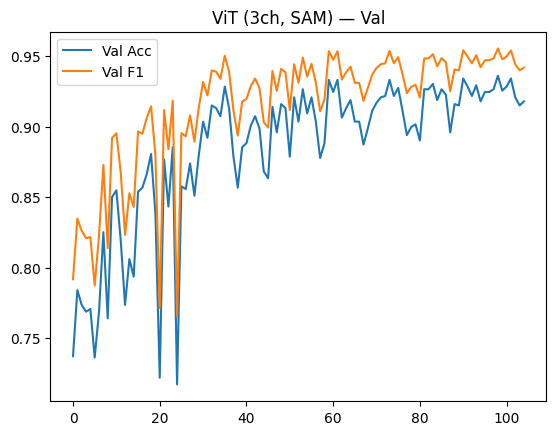

[ViT-3ch+SAM @0.5] {'acc': 0.8846, 'precision': 0.9036, 'recall': 0.9128, 'f1': 0.9082, 'auroc': np.float64(0.943), 'thr': 0.5}
[ViT-3ch+SAM @Rec] {'acc': 0.8622, 'precision': 0.8304, 'recall': 0.9795, 'f1': 0.8988, 'auroc': np.float64(0.943), 'thr': 0.135}
[ViT-3ch+SAM @0.5] {'acc': 0.8846, 'precision': 0.9036, 'recall': 0.9128, 'f1': 0.9082, 'auroc': np.float64(0.943), 'thr': 0.5}
[ViT-3ch+SAM @Rec] {'acc': 0.8622, 'precision': 0.8304, 'recall': 0.9795, 'f1': 0.8988, 'auroc': np.float64(0.943), 'thr': 0.135}


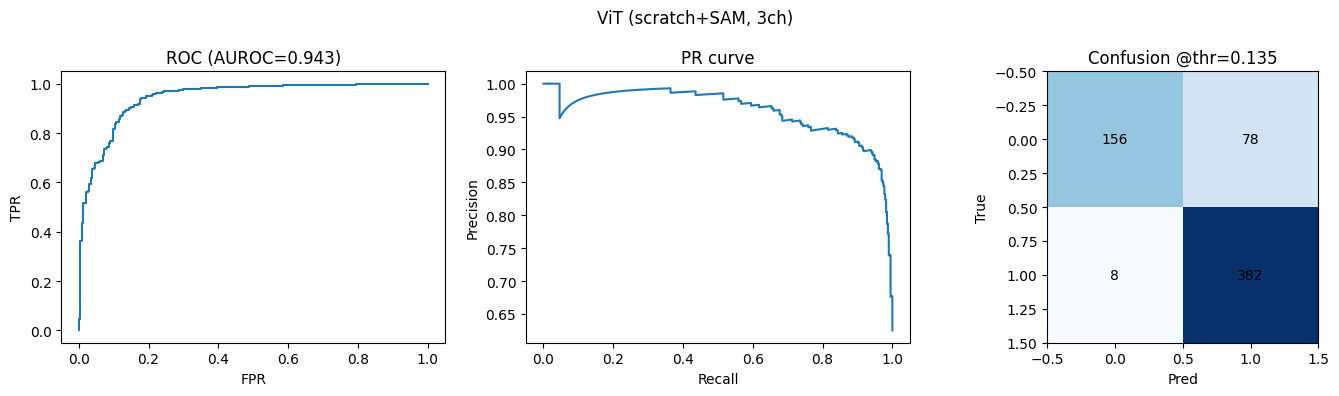

{'summary@0.5': {'acc': 0.8846153846153846,
  'precision': 0.9035532994923858,
  'recall': 0.9128205128205128,
  'f1': 0.9081632653061225,
  'auroc': np.float64(0.9429761122068815),
  'thr': 0.5},
 'summary@recall': {'acc': 0.8621794871794872,
  'precision': 0.8304347826086956,
  'recall': 0.9794871794871794,
  'f1': 0.8988235294117647,
  'auroc': np.float64(0.9429761122068815),
  'thr': 0.135},
 'threshold': 0.135,
 'time_sec': 4365.559239149094,
 'params': 21666434}

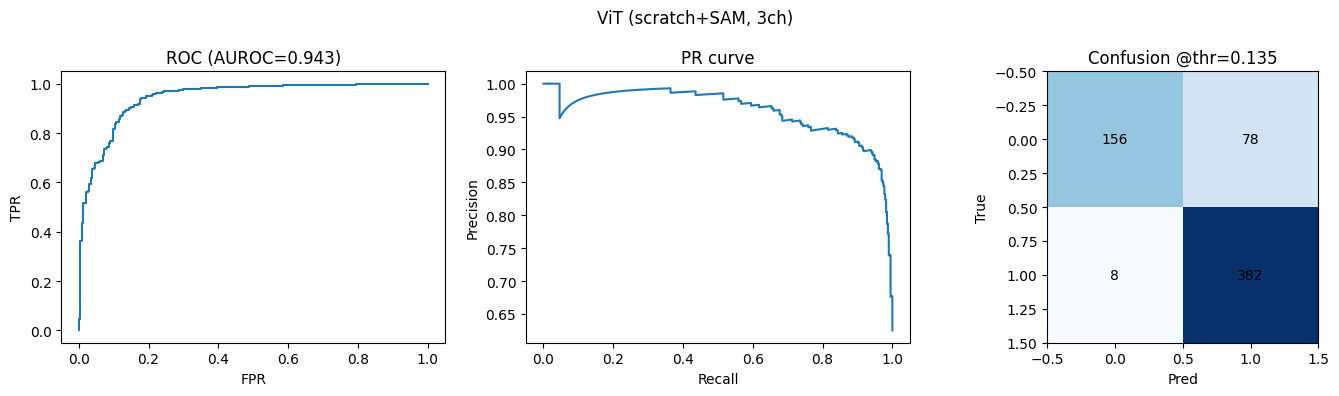

{'summary@0.5': {'acc': 0.8846153846153846,
  'precision': 0.9035532994923858,
  'recall': 0.9128205128205128,
  'f1': 0.9081632653061225,
  'auroc': np.float64(0.9429761122068815),
  'thr': 0.5},
 'summary@recall': {'acc': 0.8621794871794872,
  'precision': 0.8304347826086956,
  'recall': 0.9794871794871794,
  'f1': 0.8988235294117647,
  'auroc': np.float64(0.9429761122068815),
  'thr': 0.135},
 'threshold': 0.135,
 'time_sec': 4365.559239149094,
 'params': 21666434}

In [21]:
vit = build_vit_scratch(
    img_size=224, in_chans=3, num_classes=2,
    embed_dim=384, depth=12, heads=6, patch=16, mlp_ratio=4.0, drop=0.1
)
t0 = time.time()
vit_tr, vit_hist, vit_time = train_model(
    vit, train_loader, val_loader, DEVICE, arch="vit",
    epochs=120, base_lr=3e-4, weight_decay=0.3, label_smoothing=0.0,
    use_sam=True, sam_rho=0.2,    # per paper, SAM helps ViT a lot on small data
    use_cosine=True, warmup_epochs=5, min_lr_mult=0.01,
    monitor="va_auroc", patience=17, clip_grad_norm=1.0,
    class_weights=class_weights, llrd=False, head_lr_mult=1.0, use_amp=False,
    tag="ViT-scratch-3ch+SAM"
)
plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT (3ch, SAM) — Loss")
plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT (3ch, SAM) — Val")

va = evaluate(vit_tr, val_loader, DEVICE)
thr, *_ = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], scratch_sam.target_recall)
te = evaluate(vit_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ViT-3ch+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ViT-3ch+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ViT (scratch+SAM, 3ch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ViT (scratch+SAM, 3ch)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [22]:
# === Final comparison tables across all models in this notebook ===
# Builds two tables:
#   (A) Metrics at the threshold that achieves Recall >= 0.95 (from summary@recall)
#   (B) Metrics at fixed threshold = 0.5 (from summary@0.5)
# Requires: from src import result_registry ; each model added via add_result(name, ...)

import math, pandas as pd
from src import result_registry

TARGET_RECALL = 0.95  # what "recall >= 95%" means

if not result_registry:
    raise RuntimeError("result_registry is empty. Make sure you called add_result(...) after each model.")

def _extract_row(model_name: str, rec: dict, which: str):
    """
    which: 'summary@recall' or 'summary@0.5'
    Returns a flat row with common columns.
    """
    s = rec.get(which, {}) or {}
    # Prefer the per-summary 'thr' if present; else fall back to the top-level 'threshold'
    thr = s.get("thr", rec.get("threshold", float("nan")))
    row = {
        "model": model_name,
        "threshold": float(thr) if thr is not None and not isinstance(thr, str) else float("nan"),
        "acc": float(s.get("acc", float("nan"))),
        "precision": float(s.get("precision", float("nan"))),
        "recall": float(s.get("recall", float("nan"))),
        "f1": float(s.get("f1", float("nan"))),
        "auroc": float(s.get("auroc", float("nan"))),
        "params": rec.get("params", None),
        "time_sec": rec.get("time_sec", None),
    }
    return row

# Build both tables from the registry
rows_recall = []
rows_thr05 = []
for name, rec in result_registry.items():
    rows_recall.append(_extract_row(name, rec, "summary@recall"))
    rows_thr05.append(_extract_row(name, rec, "summary@0.5"))

df_recall = pd.DataFrame(rows_recall)
df_thr05  = pd.DataFrame(rows_thr05)

# Add convenience columns and formatting
def _format(df: pd.DataFrame, check_target=False) -> pd.DataFrame:
    df = df.copy()
    # Params in millions; training time in minutes
    if "params" in df:
        df["params (M)"] = df["params"].apply(lambda x: round(x/1e6, 2) if pd.notna(x) else math.nan)
    if "time_sec" in df:
        df["time (min)"] = df["time_sec"].apply(lambda x: round(x/60.0, 1) if pd.notna(x) else math.nan)

    # Human-friendly rounding
    if "threshold" in df: df["threshold"] = df["threshold"].round(3)
    for c in ["acc","precision","recall","f1","auroc"]:
        if c in df:
            df[c] = (df[c] * 100.0).round(2)  # show as %
    # Optional flag: did this row meet the target recall?
    if check_target and "recall" in df:
        df["meets_target(≥95%)"] = df["recall"].apply(lambda r: (pd.notna(r) and r >= TARGET_RECALL*100.0))
    # Reorder columns
    cols = ["model","threshold","acc","precision","recall","f1","auroc","params (M)","time (min)"]
    cols = [c for c in cols if c in df.columns]
    return df[cols]

# Sort by AUROC (desc) as a stable default; change to 'f1' if you prefer
df_recall = df_recall.sort_values(by="auroc", ascending=False).reset_index(drop=True)
df_thr05  = df_thr05.sort_values(by="auroc", ascending=False).reset_index(drop=True)

df_recall = _format(df_recall, check_target=True)
df_thr05  = _format(df_thr05,  check_target=False)

# Display
print("=== Table A — Metrics at threshold chosen to reach Recall ≥ 95% ===")
display(df_recall.style.format({
    "threshold": "{:.3f}",
    "acc": "{:.2f}%", "precision": "{:.2f}%", "recall": "{:.2f}%", "f1": "{:.2f}%", "auroc": "{:.2f}%",
    "params (M)": "{:.2f}", "time (min)": "{:.1f}"
}).set_properties(**{"text-align": "center"}))

print("\n=== Table B — Metrics at fixed threshold = 0.50 ===")
display(df_thr05.style.format({
    "threshold": "{:.3f}",
    "acc": "{:.2f}%", "precision": "{:.2f}%", "recall": "{:.2f}%", "f1": "{:.2f}%", "auroc": "{:.2f}%",
    "params (M)": "{:.2f}", "time (min)": "{:.1f}"
}).set_properties(**{"text-align": "center"}))

# (Optional) Save to CSV alongside the notebook
# df_recall.to_csv("results_table_recall>=95.csv", index=False)
# df_thr05.to_csv("results_table_thr=0.5.csv", index=False)


=== Table A — Metrics at threshold chosen to reach Recall ≥ 95% ===


,model,threshold,acc,precision,recall,f1,auroc,params (M),time (min)
0,"ViT (scratch+SAM, 3ch)",0.135,86.22%,83.04%,97.95%,89.88%,94.30%,21.67,72.8
1,"ResNet18 (scratch+SAM, 3ch)",0.351,84.29%,80.67%,98.46%,88.68%,93.12%,11.18,6.6
2,"CustomCNN (scratch+SAM, 3ch)",0.342,78.04%,74.85%,97.69%,84.76%,92.00%,0.48,31.1



=== Table B — Metrics at fixed threshold = 0.50 ===


,model,threshold,acc,precision,recall,f1,auroc,params (M),time (min)
0,"ViT (scratch+SAM, 3ch)",0.500,88.46%,90.36%,91.28%,90.82%,94.30%,21.67,72.8
1,"ResNet18 (scratch+SAM, 3ch)",0.500,87.98%,86.37%,95.90%,90.89%,93.12%,11.18,6.6
2,"CustomCNN (scratch+SAM, 3ch)",0.500,83.01%,81.56%,94.10%,87.38%,92.00%,0.48,31.1
